# Ablation: YOLO11s vs Baseline YOLOv8s — Deteksi Helm

Membandingkan **YOLO11s** dengan baseline **YOLOv8s** pada dataset & hyperparameter yang **sama persis** (hanya model yang berubah) — sesuai prinsip *ubah satu variabel per run* di `CLAUDE.md`.

Langkah: (1) baca config, (2) training, (3) evaluasi test, (4) tabel perbandingan, (5) visual.

## 1. Setup

In [1]:
%matplotlib inline
import sys, json, shutil
from datetime import date
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'configs').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
import os; os.chdir(REPO_ROOT)  # agar path relatif di config (data/...) resolve benar

from src.seeding import set_seed
from src.env import collect_env, print_env
from src.metrics import metrics_from_results, save_metrics
print('Repo root:', REPO_ROOT)
_ = print_env()

Repo root: /home/bdo/code/jupyter-code/foldersr/work/project-cv


ENVIRONMENT
  python          : 3.12.13
  platform        : Linux-6.8.0-124-generic-x86_64-with-glibc2.35
  cuda_available  : True
  device          : cuda:0
  gpu_name        : NVIDIA GeForce RTX 4090
  torch           : 2.8.0+cu128
  cuda            : 12.8
  ultralytics     : 8.4.65


## 2. Baca config ablation (bandingkan dengan baseline)

In [2]:
cfg = yaml.safe_load((REPO_ROOT / 'configs' / 'ablation_yolo11.yaml').read_text())
base_cfg = yaml.safe_load((REPO_ROOT / 'configs' / 'baseline_yolov8.yaml').read_text())

# Tampilkan perbedaan config (harusnya HANYA model & run_name)
diff = {k: (base_cfg.get(k), cfg.get(k)) for k in cfg if base_cfg.get(k) != cfg.get(k)}
print('Perbedaan terhadap baseline (baseline -> ablation):')
for k, (a, b) in diff.items():
    print(f'  {k}: {a}  ->  {b}')
cfg

Perbedaan terhadap baseline (baseline -> ablation):
  run_name: helm_yolov8s_roboflow  ->  helm_yolo11s_roboflow
  model: yolov8s.pt  ->  yolo11s.pt


{'run_name': 'helm_yolo11s_roboflow',
 'project_dir': 'experiments',
 'data': 'data/helmet-roboflow/data.yaml',
 'model': 'yolo11s.pt',
 'epochs': 100,
 'imgsz': 1280,
 'batch': -1,
 'optimizer': 'auto',
 'lr0': 0.01,
 'patience': 25,
 'seed': 42,
 'deterministic': True,
 'device': 0,
 'augment': {'hsv_h': 0.015,
  'hsv_s': 0.7,
  'hsv_v': 0.4,
  'fliplr': 0.5,
  'mosaic': 1.0,
  'scale': 0.5}}

## 3. Training YOLO11s

Set seed (reproducible), muat `yolo11s.pt` (transfer learning COCO), latih. Sel ini memakan waktu (~20–30 menit di RTX 4090).

In [3]:
from ultralytics import YOLO

seed = set_seed(cfg.get('seed', 42), cfg.get('deterministic', True))
run_name = f"{cfg['run_name']}_{date.today():%Y%m%d}"
run_dir = REPO_ROOT / cfg['project_dir'] / run_name
best_pt = run_dir / 'weights' / 'best.pt'
print('Run:', run_name, '| seed:', seed)

if best_pt.exists():
    # Sudah dilatih sebelumnya -> muat saja (re-eksekusi notebook jadi cepat)
    print(f'✓ Model sudah ada, lewati training: {best_pt}')
    model = YOLO(str(best_pt))
else:
    model = YOLO(cfg['model'])
    _ = model.train(
        data=cfg['data'], epochs=cfg['epochs'], imgsz=cfg['imgsz'], batch=cfg['batch'],
        optimizer=cfg.get('optimizer', 'auto'), lr0=cfg.get('lr0', 0.01),
        patience=cfg.get('patience', 25), seed=seed, deterministic=cfg.get('deterministic', True),
        device=cfg.get('device', 0), project=str(REPO_ROOT / cfg['project_dir']),
        name=run_name, exist_ok=True, **cfg.get('augment', {}),
    )
    # Catat config + env untuk reproducibility (seperti scripts/train.py)
    run_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(REPO_ROOT / 'configs' / 'ablation_yolo11.yaml', run_dir / 'config_used.yaml')
    (run_dir / 'env.json').write_text(json.dumps({'seed': seed, **collect_env()}, indent=2))

print('best.pt:', best_pt)

Run: helm_yolo11s_roboflow_20260611 | seed: 42
✓ Model sudah ada, lewati training: /home/bdo/code/jupyter-code/foldersr/work/project-cv/experiments/helm_yolo11s_roboflow_20260611/weights/best.pt
best.pt: /home/bdo/code/jupyter-code/foldersr/work/project-cv/experiments/helm_yolo11s_roboflow_20260611/weights/best.pt


## 4. Evaluasi di split test

In [4]:
best_pt = run_dir / 'weights' / 'best.pt'
eval_batch = cfg['batch'] if cfg['batch'] and cfg['batch'] > 0 else 16
res = YOLO(str(best_pt)).val(data=cfg['data'], imgsz=cfg['imgsz'], batch=eval_batch,
                             split='test', device=cfg.get('device', 0))
fps = 1000.0 / res.speed['inference'] if getattr(res, 'speed', {}).get('inference') else None
m_yolo11 = metrics_from_results(res, fps=fps)
save_metrics(m_yolo11, run_dir)
m_yolo11

Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24217MiB)


YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5428.4±619.6 MB/s, size: 146.2 KB)


val: Scanning /home/bdo/code/jupyter-code/foldersr/work/project-cv/data/helmet-roboflow/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 41.9Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 1/7 1.4it/s 0.2s<4.2s

...

          motorcyclist         98        151       0.95      0.974      0.971      0.809


Speed: 3.6ms preprocess, 5.1ms inference, 0.0ms loss, 0.7ms postprocess per image


Results saved to /home/bdo/code/jupyter-code/foldersr/work/project-cv/runs/detect/val-5


✓ Metrik disimpan ke /home/bdo/code/jupyter-code/foldersr/work/project-cv/experiments/helm_yolo11s_roboflow_20260611/metrics.{json,csv}
    mAP50     : 0.9580
    mAP50_95  : 0.6877
    precision : 0.9480
    recall    : 0.9403
    fps       : 194.6991


{'mAP50': 0.9579722229746723,
 'mAP50_95': 0.6876980292937447,
 'precision': 0.9480131295493347,
 'recall': 0.9402562206231183,
 'fps': 194.69905196859992}

## 5. Tabel perbandingan: YOLOv8s vs YOLO11s

In [5]:
base_dir = REPO_ROOT / 'experiments' / 'helm_yolov8s_roboflow_20260611'
m_yolov8 = json.loads((base_dir / 'metrics.json').read_text())

compare = pd.DataFrame({'YOLOv8s (baseline)': m_yolov8, 'YOLO11s (ablation)': m_yolo11}).T
compare = compare[['mAP50', 'mAP50_95', 'precision', 'recall', 'fps']]
compare['delta_mAP50'] = compare['mAP50'] - compare.loc['YOLOv8s (baseline)', 'mAP50']
compare.round(4)

,mAP50,mAP50_95,precision,recall,fps,delta_mAP50
YOLOv8s (baseline),0.9604,0.6890,0.9571,0.9408,295.9299,0.0000
YOLO11s (ablation),0.9580,0.6877,0.9480,0.9403,194.6991,-0.0024


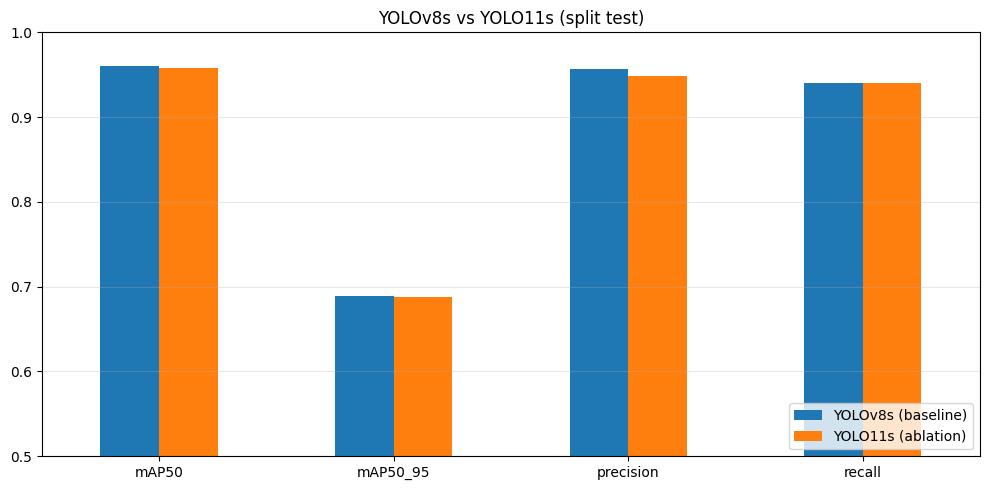

In [6]:
# Bar chart perbandingan metrik akurasi
ax = compare[['mAP50', 'mAP50_95', 'precision', 'recall']].T.plot.bar(figsize=(10, 5), rot=0)
ax.set_title('YOLOv8s vs YOLO11s (split test)')
ax.set_ylim(0.5, 1.0); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Kurva training YOLO11s

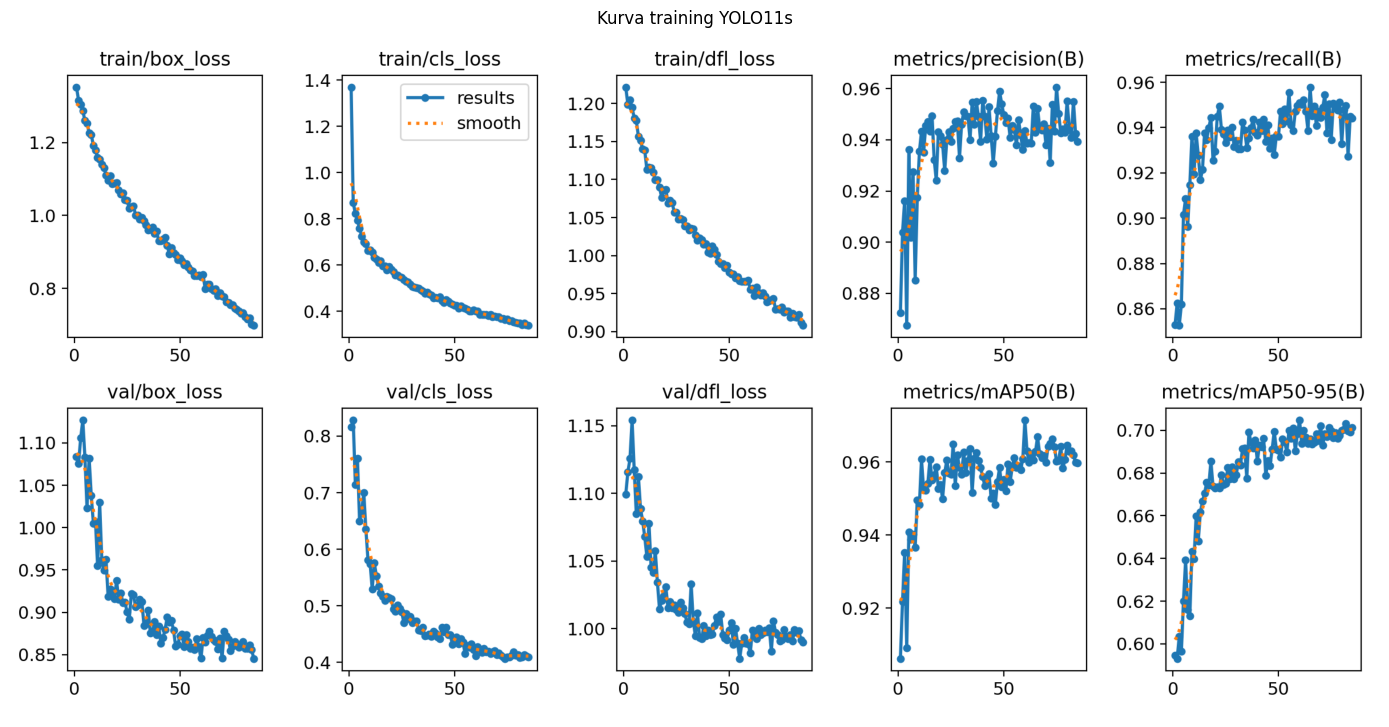

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(mpimg.imread(run_dir / 'results.png')); ax.axis('off')
ax.set_title('Kurva training YOLO11s'); plt.tight_layout(); plt.show()

## 7. Kesimpulan

Lihat tabel di sel 5 — model dengan **mAP50 / mAP50-95** lebih tinggi adalah pemenang ablation; perhatikan juga **FPS** (trade-off kecepatan). Karena hanya `model` yang berbeda, selisihnya dapat diatribusikan ke arsitektur.